<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/52_feature_engineering_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
X, y = make_regression(
    n_samples=500,
    n_features=2,
    noise=20,
    random_state=42
)

print(X.shape)

(500, 2)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
lr_original = LinearRegression()

lr_original.fit(
    X_train,
    y_train
)

pred_original = lr_original.predict(
    X_test
)

In [5]:
mae_original = mean_absolute_error(
    y_test,
    pred_original
)

rmse_original = np.sqrt(
    mean_squared_error(
        y_test,
        pred_original
    )
)

r2_original = r2_score(
    y_test,
    pred_original
)

print("Original Features")
print("MAE :", round(mae_original,2))
print("RMSE:", round(rmse_original,2))
print("R²  :", round(r2_original,4))

Original Features
MAE : 14.31
RMSE: 18.67
R²  : 0.4961


In [6]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train
)

X_test_poly = poly.transform(
    X_test
)

print("Original Shape :", X_train.shape)
print("New Shape      :", X_train_poly.shape)

Original Shape : (400, 2)
New Shape      : (400, 5)


In [7]:
lr_poly = LinearRegression()

lr_poly.fit(
    X_train_poly,
    y_train
)

pred_poly = lr_poly.predict(
    X_test_poly
)

In [8]:
mae_poly = mean_absolute_error(
    y_test,
    pred_poly
)

rmse_poly = np.sqrt(
    mean_squared_error(
        y_test,
        pred_poly
    )
)

r2_poly = r2_score(
    y_test,
    pred_poly
)

print("Polynomial Features")
print("MAE :", round(mae_poly,2))
print("RMSE:", round(rmse_poly,2))
print("R²  :", round(r2_poly,4))

Polynomial Features
MAE : 14.38
RMSE: 18.68
R²  : 0.496


In [9]:
comparison = pd.DataFrame({
    "Approach":[
        "Original Features",
        "Polynomial Features"
    ],

    "MAE":[
        mae_original,
        mae_poly
    ],

    "RMSE":[
        rmse_original,
        rmse_poly
    ],

    "R²":[
        r2_original,
        r2_poly
    ]
})

comparison

,Approach,MAE,RMSE,R²
0,Original Features,14.310774,18.672985,0.496132
1,Polynomial Features,14.378789,18.675553,0.495994


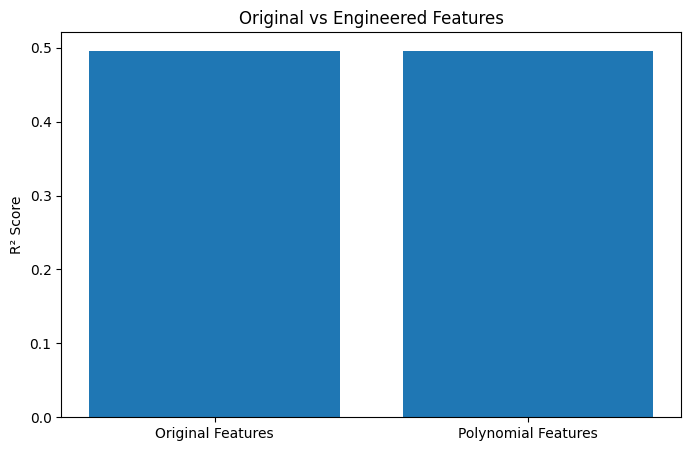

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Approach"],
    comparison["R²"]
)

plt.ylabel("R² Score")

plt.title(
    "Original vs Engineered Features"
)

plt.show()

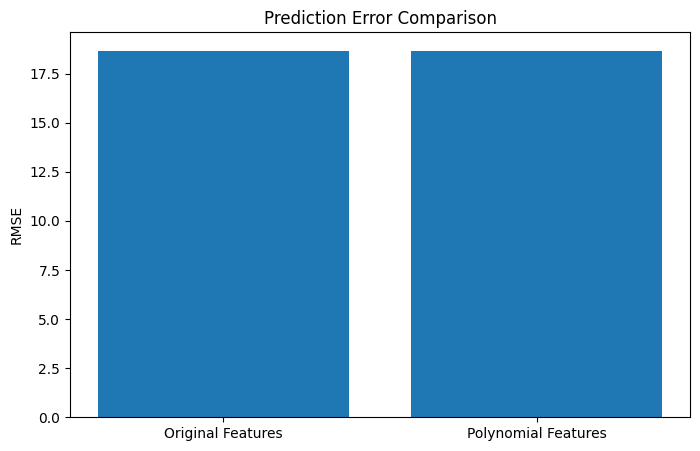

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Approach"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")

plt.title(
    "Prediction Error Comparison"
)

plt.show()

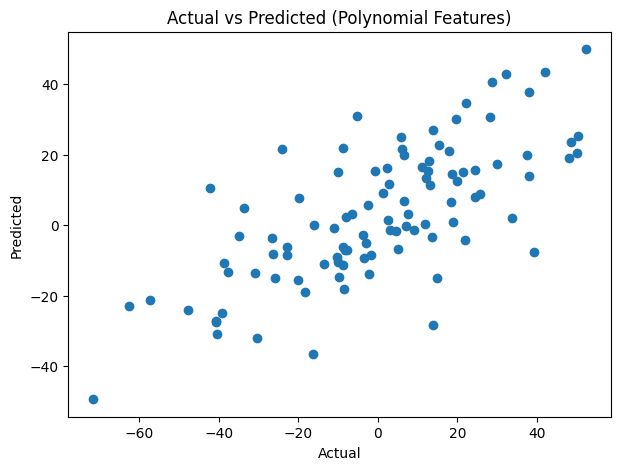

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    pred_poly
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted (Polynomial Features)"
)

plt.show()

In [13]:
if r2_poly > r2_original:
    print(
        "Feature Engineering Improved Performance"
    )
else:
    print(
        "No Significant Improvement"
    )

No Significant Improvement


## Conclusion

Feature Engineering was performed using Polynomial Features.

Observations:
- New interaction and squared features were generated.
- Model performance before and after feature engineering was compared.
- Polynomial Features can help Linear Regression capture more complex relationships.
- Feature Engineering can improve performance without changing the algorithm.